# Base 03 — Seleção Brasileira: gols marcados por mês (1990–2022)

Pipeline completo da base 03: documentação, EDA, regularização da lista de partidas em série mensal, limpeza, STL, features sem vazamento, tuning temporal, walk-forward, MAE, resíduos e interpretação. A estrutura espelha o `base_05.ipynb`.

**Execução:** o GridSearch temporal é pesado (SARIMAX com 144 configurações × 4 origens, Random Forest com 324 configurações × 5 folds). Rode *Restart & Run All* a partir da pasta `notebooks/`; os outputs ainda não foram gerados nesta versão.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from itertools import product
import json
import pickle
import time
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

BASE_ID = "base_03"
RANDOM_STATE = 42
DATA_DIR = Path("../data") / BASE_ID
ARTIFACT_DIR = Path("../artifacts") / BASE_ID
RAW_FILE = DATA_DIR / "brazil.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

assert RAW_FILE.exists(), f"Arquivo raw ausente: {RAW_FILE}"
print({
    "python": __import__("sys").version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "matplotlib": matplotlib.__version__,
    "pyarrow": pyarrow.__version__,
})

{'python': '3.11.2', 'numpy': '1.26.4', 'pandas': '2.2.3', 'sklearn': '1.8.0', 'statsmodels': '0.14.6', 'matplotlib': '3.8.3', 'pyarrow': '18.1.0'}


## A–C. Documentação, EDA e limpeza

**Fonte e conteúdo.** `brazil.csv` é a base fornecida ao grupo: o histórico de partidas da seleção brasileira masculina entre 20/09/1914 e 09/12/2022 (1.034 linhas, uma por partida). Cada linha traz a data, o confronto, o resultado do ponto de vista do Brasil, o placar e a competição.

| Coluna raw | Tipo | Significado |
|---|---|---|
| `Date` | texto `dd Mon yyyy` | data da partida |
| `Match` | texto `A v B` | confronto; o time citado primeiro é o mandante e é ele quem aparece primeiro no placar |
| `Result` | `W`/`D`/`L` | resultado para o Brasil (empates decididos nos pênaltis aparecem como `W` ou `L`) |
| `Score` | texto | placar na ordem de `Match`; pode ter pênaltis entre parênteses ou o agregado (`Agg:`) |
| `Competition` | texto | competição (amistoso, Copa do Mundo e eliminatórias, Copa América, etc.) |

**Esta base não é uma série temporal regular.** São partidas em datas irregulares, e os requisitos do enunciado (§4) pedem alvo numérico, frequência regular e pelo menos duas variáveis externas. A regularização adotada é **agregar as partidas por mês**, numa janela com cobertura estável.

**Série modelada.** Frequência mensal, de jan/1990 a dez/2022 (396 meses; a escolha da janela é justificada na célula seguinte). O alvo é `goals_for`, os **gols marcados pelo Brasil no mês** (soma de todas as partidas do arquivo). Mês sem partida vale 0 gol: é uma observação verdadeira (não houve jogo), e não uma imputação.

| Coluna | Tipo | Significado | Papel | `availability` |
|---|---|---|---|---|
| `Date` | datetime | 1º dia do mês | índice | `known_ahead` |
| `goals_for` | int | gols marcados pelo Brasil no mês | alvo | — |
| `goals_against` | int | gols sofridos no mês | externa | `lag_only` |
| `matches` | int | partidas disputadas no mês | externa | `lag_only` |
| `competitive_matches` | int | partidas de competição (`Competition` ≠ `International Friendly`) | externa | `lag_only` |
| `wins` | int | vitórias no mês (`Result == "W"`, inclui pênaltis) | externa | `lag_only` |
| mês e ciclo da Copa do Mundo | calendário | posição no ano e no ciclo de 4 anos (Copas em 1990, 1994, …, 2022) | externa | `known_ahead` |

Na origem `t` (fim do mês `t`), só entram valores observados até `t`. As externas de resultado (`goals_against`, `matches`, `competitive_matches`, `wins`) só podem ser usadas defasadas. Já o calendário do mês previsto e o ano de Copa do Mundo são conhecidos com antecedência.

**Limitação.** As variáveis externas são derivadas do mesmo arquivo, não há covariável independente (como ranking FIFA ou calendário oficial). Isso deve ser discutido no relatório.

,value
raw_rows,1034
start,1914-09-20
end,2022-12-09
duplicate_rows,0
duplicate_dates,3
out_of_order_rows,1
missing_score,1
missing_competition,1
invalid_result_code,1
scores_with_penalties_or_agg,15


Linhas removidas por registro inválido:


,Date,Match,Result,Score,Competition
1014,2021-09-05,Brazil v Argentina,FIFA World Cup,NaN,NaN


Janela 1990-01 a 2022-12: mínimo de 10 partidas/ano (exceto 2020, com 4, efeito da pandemia).


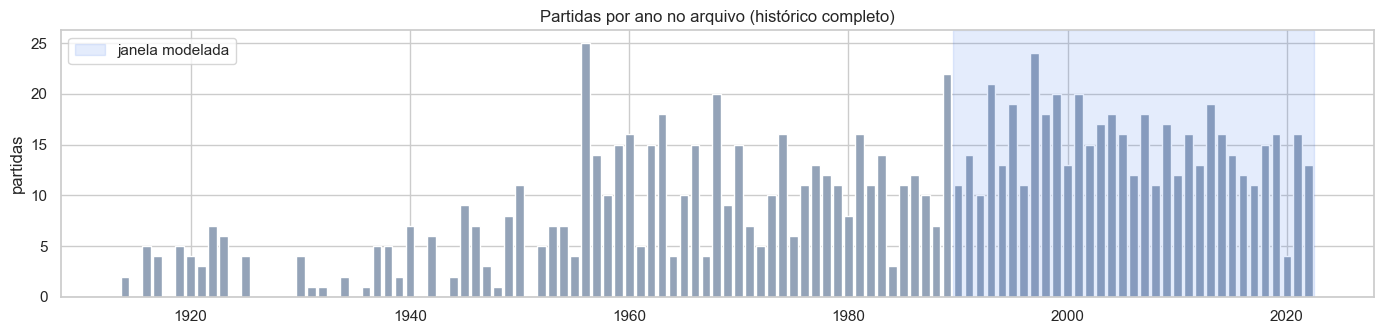

,value
months,396
start,1990-01-01
end,2022-12-01
missing_total,0
duplicate_dates,0
irregular_steps,0
matches_in_window,495
matches_in_monthly,495
empty_months,157
empty_months_share,0.396


Meses com gols acima de Q3 + 3×IQR: 8; preservados.


,Date,goals_for,matches
53,1994-06-01,19,6
89,1997-06-01,27,9
114,1999-07-01,17,8
149,2002-06-01,18,7
185,2005-06-01,17,7
233,2009-06-01,20,7
281,2013-06-01,19,7
353,2019-06-01,17,6


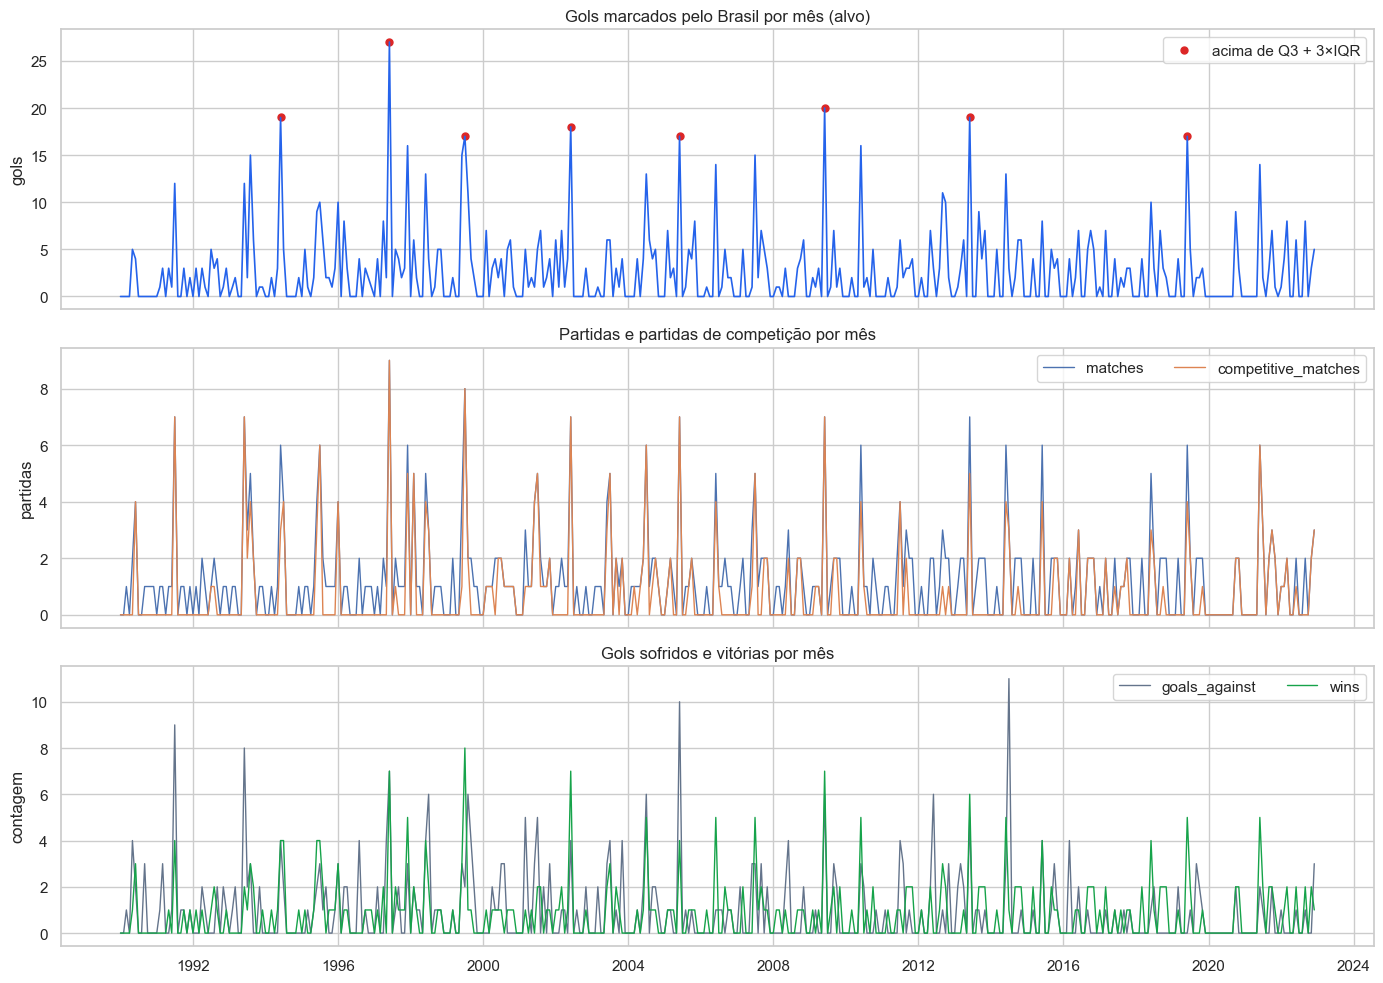

Série mensal limpa salva: (396, 6)


In [2]:
raw = pd.read_csv(RAW_FILE)
expected_columns = ["Date", "Match", "Result", "Score", "Competition"]
assert raw.columns.tolist() == expected_columns

matches = raw.copy()
matches["Date"] = pd.to_datetime(matches["Date"], format="%d %b %Y", errors="raise")
out_of_order_rows = int((matches["Date"].diff().dt.days < 0).sum())
matches = matches.sort_values("Date", kind="stable").reset_index(drop=True)

audit = {
    "raw_rows": len(raw),
    "start": matches["Date"].min().date(),
    "end": matches["Date"].max().date(),
    "duplicate_rows": int(raw.duplicated().sum()),
    "duplicate_dates": int(matches["Date"].duplicated().sum()),
    "out_of_order_rows": out_of_order_rows,
    "missing_score": int(matches["Score"].isna().sum()),
    "missing_competition": int(matches["Competition"].isna().sum()),
    "invalid_result_code": int((~matches["Result"].isin(["W", "D", "L"])).sum()),
    "scores_with_penalties_or_agg": int(matches["Score"].str.contains(r"\(|Agg", na=False).sum()),
}
display(pd.Series(audit, name="value").to_frame())

# Registro inválido: partida suspensa (05/09/2021) com `Result` deslocado e sem placar/competição.
invalid_rows = matches[~matches["Result"].isin(["W", "D", "L"]) | matches["Score"].isna()]
print("Linhas removidas por registro inválido:")
display(invalid_rows)
assert len(invalid_rows) == 1, "Esperada exatamente 1 linha inválida no raw congelado"
matches = matches.drop(index=invalid_rows.index).reset_index(drop=True)

# Placar: primeiro par de dígitos (ignora pênaltis e agregado); orientação pela posição do Brasil em `Match`.
score = matches["Score"].str.strip().str.extract(r"^(\d+)-(\d+)").astype(int)
brazil_first = matches["Match"].str.startswith("Brazil v ")
brazil_last = matches["Match"].str.endswith(" v Brazil")
assert (brazil_first ^ brazil_last).all()
matches["goals_for"] = np.where(brazil_first, score[0], score[1])
matches["goals_against"] = np.where(brazil_first, score[1], score[0])

# Consistência com `Result`: só empates no tempo normal podem aparecer como W/L (pênaltis).
implied = np.sign(matches["goals_for"] - matches["goals_against"]).map({1: "W", 0: "D", -1: "L"})
assert ((implied == matches["Result"]) | (implied == "D")).all()

matches["is_competitive"] = (matches["Competition"] != "International Friendly").astype(int)
matches["is_win"] = (matches["Result"] == "W").astype(int)

# Cobertura anual: define a janela em que "sem partida no mês" significa "não houve jogo".
WINDOW_START = pd.Timestamp("1990-01-01")
WINDOW_END = pd.Timestamp("2022-12-01")
COVID_YEAR = 2020
matches_per_year = matches.groupby(matches["Date"].dt.year).size()
window_years = matches_per_year.loc[WINDOW_START.year:WINDOW_END.year]
assert window_years.drop(COVID_YEAR).min() >= 10, "Cobertura anual insuficiente na janela"
print(f"Janela {WINDOW_START:%Y-%m} a {WINDOW_END:%Y-%m}: mínimo de {window_years.drop(COVID_YEAR).min()} partidas/ano "
      f"(exceto {COVID_YEAR}, com {matches_per_year[COVID_YEAR]}, efeito da pandemia).")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(matches_per_year.index, matches_per_year.values, color="#94a3b8")
ax.axvspan(WINDOW_START.year - 0.5, WINDOW_END.year + 0.5, color="#2563eb", alpha=0.12, label="janela modelada")
ax.set(title="Partidas por ano no arquivo (histórico completo)", ylabel="partidas")
ax.legend()
plt.tight_layout()
plt.show()

# Agregação mensal: soma dos gols/contagens; meses sem jogo entram como 0.
window = matches[(matches["Date"] >= WINDOW_START) & (matches["Date"] <= WINDOW_END + pd.offsets.MonthEnd(0))]
monthly = (
    window.assign(Date=window["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Date")
    .agg(
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        matches=("goals_for", "size"),
        competitive_matches=("is_competitive", "sum"),
        wins=("is_win", "sum"),
    )
)
full_index = pd.date_range(WINDOW_START, WINDOW_END, freq="MS", name="Date")
empty_months = len(full_index.difference(monthly.index))
monthly = monthly.reindex(full_index, fill_value=0).astype(int).reset_index()

integrity = {
    "months": len(monthly),
    "start": monthly["Date"].min().date(),
    "end": monthly["Date"].max().date(),
    "missing_total": int(monthly.isna().sum().sum()),
    "duplicate_dates": int(monthly["Date"].duplicated().sum()),
    "irregular_steps": int((~monthly["Date"].diff().dropna().dt.days.between(28, 31)).sum()),
    "matches_in_window": int(len(window)),
    "matches_in_monthly": int(monthly["matches"].sum()),
    "empty_months": empty_months,
    "empty_months_share": round(empty_months / len(monthly), 3),
}
display(pd.Series(integrity, name="value").to_frame())
assert integrity["months"] == 396
assert integrity["missing_total"] == 0 and integrity["duplicate_dates"] == 0
assert integrity["irregular_steps"] == 0
assert integrity["matches_in_window"] == integrity["matches_in_monthly"]
assert monthly["goals_for"].sum() == window["goals_for"].sum()

# Outliers informativos no alvo: não removidos, pois concentram torneios reais (Copa do Mundo, Copa América).
q1, q3 = monthly["goals_for"].quantile([0.25, 0.75])
outlier_mask = monthly["goals_for"] > q3 + 3 * (q3 - q1)
print(f"Meses com gols acima de Q3 + 3×IQR: {int(outlier_mask.sum())}; preservados.")
display(monthly.loc[outlier_mask, ["Date", "goals_for", "matches"]])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(monthly["Date"], monthly["goals_for"], color="#2563eb", linewidth=1.2)
axes[0].scatter(monthly.loc[outlier_mask, "Date"], monthly.loc[outlier_mask, "goals_for"], s=25, color="#dc2626", label="acima de Q3 + 3×IQR")
axes[0].legend()
axes[0].set(title="Gols marcados pelo Brasil por mês (alvo)", ylabel="gols")
axes[1].plot(monthly["Date"], monthly["matches"], label="matches", linewidth=1)
axes[1].plot(monthly["Date"], monthly["competitive_matches"], label="competitive_matches", linewidth=1)
axes[1].legend(ncol=2)
axes[1].set(ylabel="partidas", title="Partidas e partidas de competição por mês")
axes[2].plot(monthly["Date"], monthly["goals_against"], color="#64748b", linewidth=1, label="goals_against")
axes[2].plot(monthly["Date"], monthly["wins"], color="#16a34a", linewidth=1, label="wins")
axes[2].legend(ncol=2)
axes[2].set(ylabel="contagem", title="Gols sofridos e vitórias por mês")
plt.tight_layout()
plt.show()

cleaned = monthly.copy()
cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv", index=False)
assert (DATA_DIR / f"cleaned_{BASE_ID}.csv").exists()
print("Série mensal limpa salva:", cleaned.shape)

### Decisões de limpeza

| Etapa | Decisão | Justificativa |
|---|---|---|
| Parse de `Date` | `pd.to_datetime(format="%d %b %Y")` e ordenação estável | o texto raw é `dd Mon yyyy`; uma linha está fora de ordem |
| Registro inválido | remover a linha de 05/09/2021 (Brasil × Argentina) | partida suspensa: `Result` traz o nome da competição e não há placar |
| Duplicidade de datas | manter | três datas têm dois jogos com adversários diferentes; nenhuma linha é duplicada |
| Placar | primeiro par de dígitos, orientado pela posição do Brasil em `Match` | pênaltis e agregado não contam como gols; checado contra `Result` |
| Frequência | agregação mensal em janela com cobertura estável (jan/1990 a dez/2022) | antes de 1956 o arquivo tem lacunas de anos inteiros e, até 1989, anos com poucas partidas; na janela há pelo menos 10 partidas/ano (exceto 2020) |
| Mês sem partida | valor 0 | é a contagem real de jogos no arquivo, válida porque a cobertura anual é estável |
| Missing | nenhuma imputação | a série mensal não tem valores ausentes |
| Outliers | preservar | meses altos correspondem a torneios com vários jogos |
| Alvo | nível (gols/mês), sem transformação | mantém o MAE em gols por mês; a série tem zeros, então log e modelos multiplicativos não se aplicam |

O raw não é regravado. A série limpa preserva as partidas da janela (verificado por contagem e soma de gols).

## D. STL, ACF/PACF e força da sazonalidade

O teste final não entra nestes diagnósticos: tudo abaixo usa apenas o período de desenvolvimento. Comparamos a força da sazonalidade para `m ∈ {6, 12, 24, 48}` (semestre, ano, dois anos e ciclo de 4 anos da Copa do Mundo). O `m=12` é o candidato de domínio, porque as datas FIFA concentram jogos em meses específicos; o `m=48` testa o ciclo da Copa.

ACF/PACF são plotados no nível, na primeira diferença e na diferença sazonal de 12 meses, para orientar `d`, `D` e as ordens `(p, q)`, `(P, Q)`.

{'development_end': Timestamp('2018-12-01 00:00:00'), 'test_start': Timestamp('2019-01-01 00:00:00'), 'test_observations': 48}


,series,adf_stat,p_value,lags,n,crit_5pct,stationary_5pct
0,goals_for (nível),-4.547400,1.612919e-04,12,335,-2.870207,True
1,goals_for (1ª diferença),-12.013542,3.140352e-22,11,335,-2.870207,True
2,goals_for (diferença sazonal 12),-9.442059,4.864927e-16,11,324,-2.870502,True


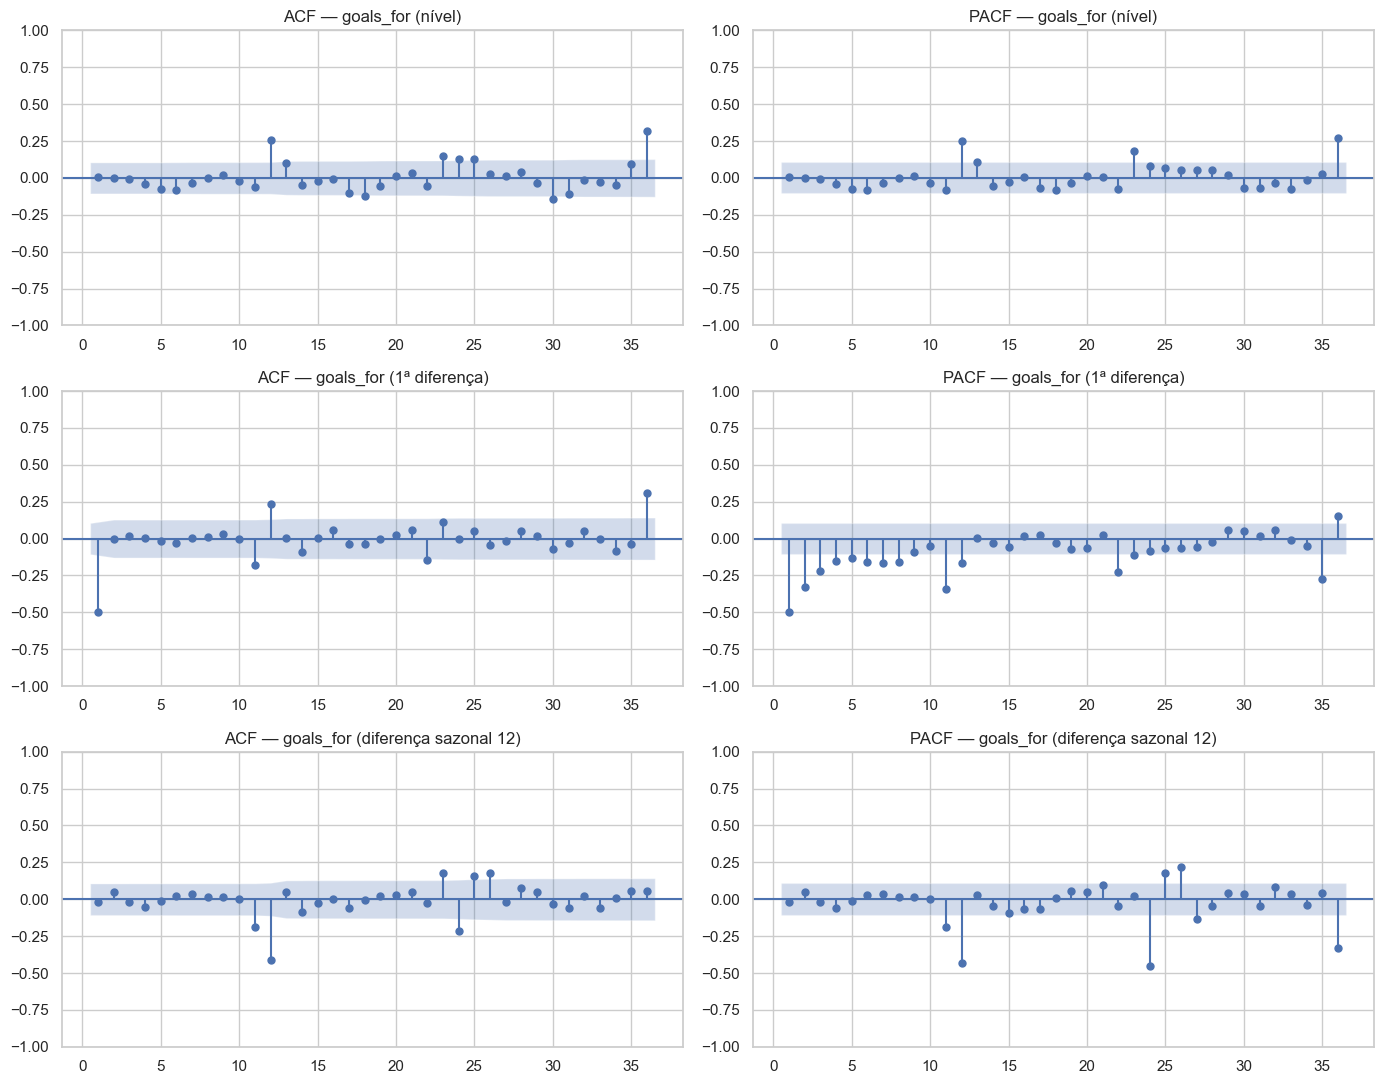

,m,seasonality_strength
3,48,0.493814
2,24,0.279612
1,12,0.173059
0,6,0.037151


Força da sazonalidade no desenvolvimento (m=12, domínio): 0.1731
Maior Fs no desenvolvimento: m=48


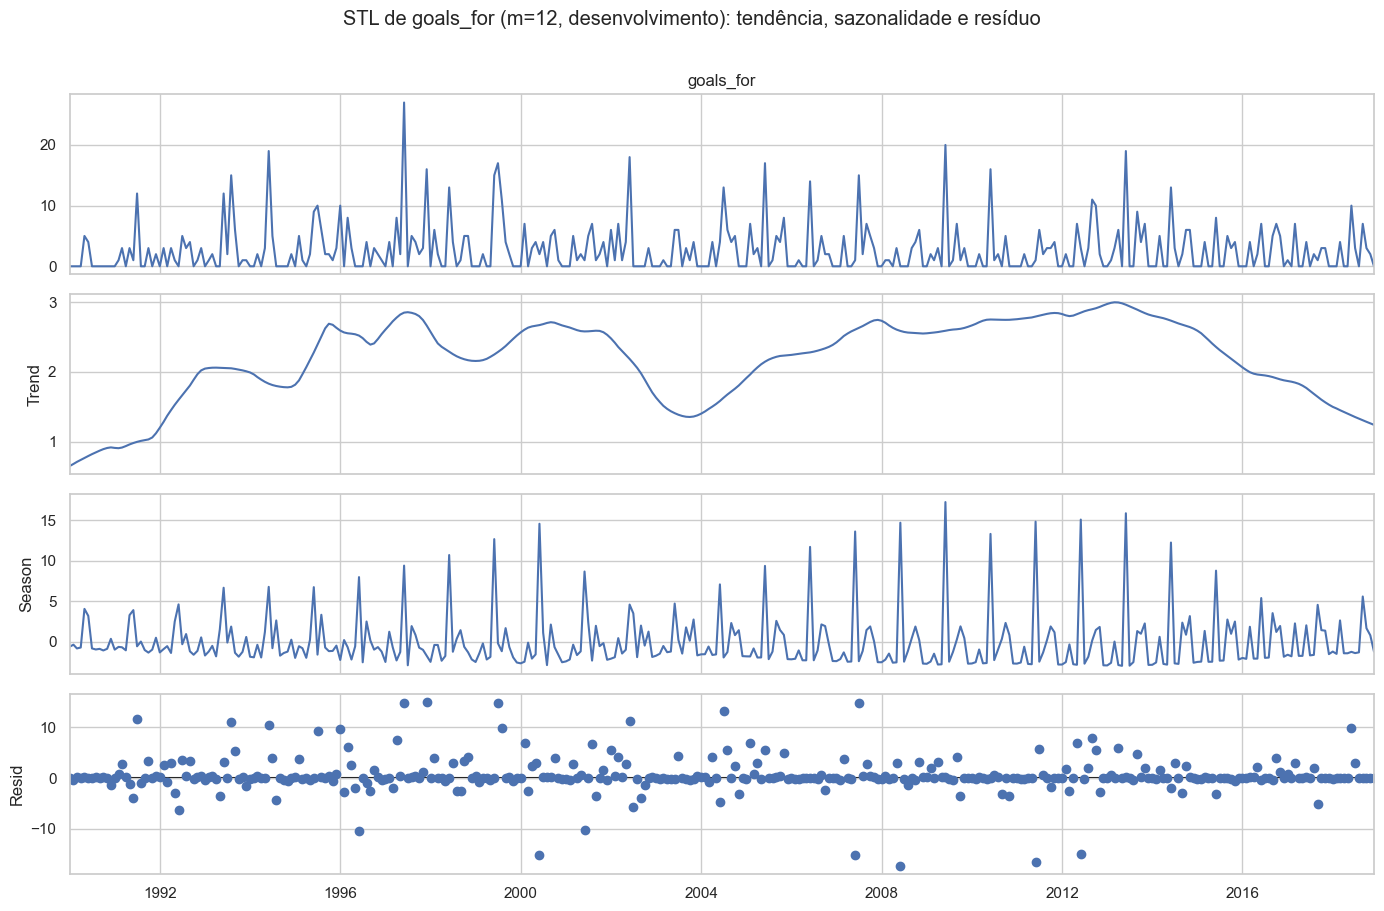

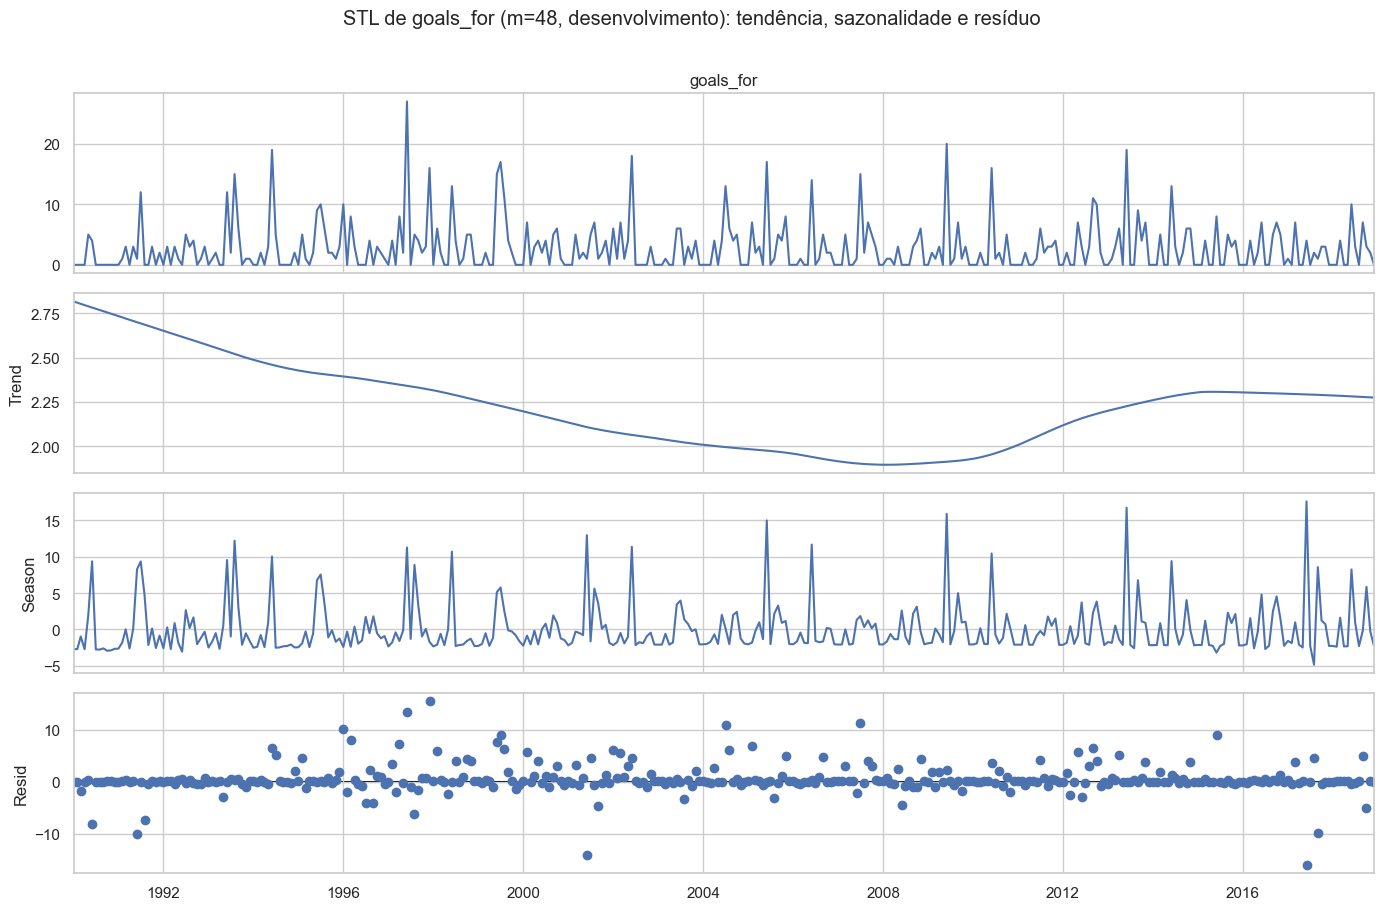

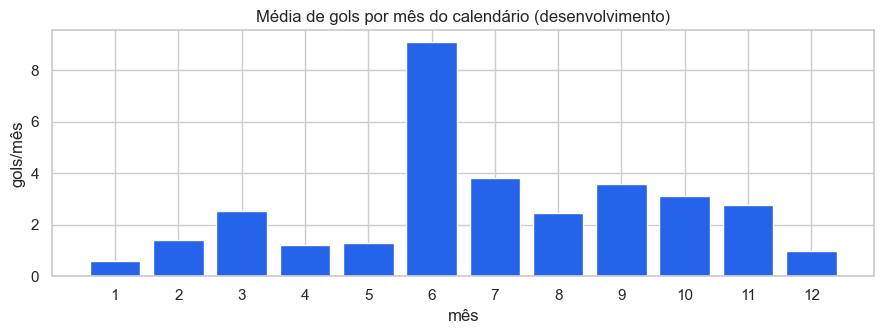

In [3]:
HORIZON = 1
ORIGIN_STEP = 1
TRAIN_MIN_OBS = 120
TEST_OBS = 48
SEASONAL_PERIOD = 12
PERIOD_CANDIDATES = [6, 12, 24, 48]

test_start_idx = len(cleaned) - TEST_OBS
development_end = cleaned.loc[test_start_idx - 1, "Date"]
test_start = cleaned.loc[test_start_idx, "Date"]
print({"development_end": development_end, "test_start": test_start, "test_observations": TEST_OBS})

development_target = pd.Series(
    cleaned.loc[:test_start_idx - 1, "goals_for"].to_numpy(dtype=float),
    index=pd.DatetimeIndex(cleaned.loc[:test_start_idx - 1, "Date"], freq="MS"),
    name="goals_for",
)


def adf_summary(series, name):
    series = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(series, autolag="AIC")
    return {
        "series": name,
        "adf_stat": float(stat),
        "p_value": float(pvalue),
        "lags": int(usedlag),
        "n": int(nobs),
        "crit_5pct": float(crit["5%"]),
        "stationary_5pct": pvalue < 0.05,
    }


level = development_target
diff1 = development_target.diff().dropna()
seasonal_diff = development_target.diff(SEASONAL_PERIOD).dropna()
display(pd.DataFrame([
    adf_summary(level, "goals_for (nível)"),
    adf_summary(diff1, "goals_for (1ª diferença)"),
    adf_summary(seasonal_diff, f"goals_for (diferença sazonal {SEASONAL_PERIOD})"),
]))

acf_lags = 36
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (series, title) in enumerate([
    (level, "goals_for (nível)"),
    (diff1, "goals_for (1ª diferença)"),
    (seasonal_diff, f"goals_for (diferença sazonal {SEASONAL_PERIOD})"),
]):
    plot_acf(series, lags=acf_lags, ax=axes[row, 0], zero=False)
    plot_pacf(series, lags=acf_lags, ax=axes[row, 1], zero=False, method="ywm")
    axes[row, 0].set_title(f"ACF — {title}")
    axes[row, 1].set_title(f"PACF — {title}")
plt.tight_layout()
plt.show()

seasonality_rows = []
stl_by_period = {}
for period in PERIOD_CANDIDATES:
    fitted = STL(development_target, period=period, robust=True).fit()
    strength = max(
        0.0,
        1.0 - np.var(fitted.resid, ddof=1) / np.var(fitted.seasonal + fitted.resid, ddof=1),
    )
    stl_by_period[period] = fitted
    seasonality_rows.append({"m": period, "seasonality_strength": strength})
seasonality_table = pd.DataFrame(seasonality_rows).sort_values("seasonality_strength", ascending=False)
display(seasonality_table)
best_m = int(seasonality_table.iloc[0]["m"])
seasonality_strength = float(seasonality_table.loc[seasonality_table["m"] == SEASONAL_PERIOD, "seasonality_strength"].iloc[0])
print(f"Força da sazonalidade no desenvolvimento (m={SEASONAL_PERIOD}, domínio): {seasonality_strength:.4f}")
print(f"Maior Fs no desenvolvimento: m={best_m}")

for period in [SEASONAL_PERIOD, 48]:
    fig = stl_by_period[period].plot()
    fig.set_size_inches(14, 9)
    plt.suptitle(f"STL de goals_for (m={period}, desenvolvimento): tendência, sazonalidade e resíduo", y=1.01)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(9, 3.5))
monthly_profile = development_target.groupby(development_target.index.month).mean()
ax.bar(monthly_profile.index, monthly_profile.values, color="#2563eb")
ax.set(title="Média de gols por mês do calendário (desenvolvimento)", xlabel="mês", ylabel="gols/mês", xticks=range(1, 13))
plt.tight_layout()
plt.show()

**Leitura esperada dos diagnósticos (conferir com as saídas executadas).** A série é assimétrica e cheia de zeros: os gols se concentram em janelas de jogos da FIFA e em torneios (Copa América e Copa do Mundo, sobretudo em junho e julho). A tendência tende a ser pouco marcada (a média anual de jogos é estável na janela), com quedas em 2020 pela pandemia. O ADF e a ACF do nível indicam se há necessidade de diferenciação; a diferença sazonal mostra se a estrutura anual permanece. A tabela de $F_s$ compara os `m` candidatos sem olhar o teste, e o gráfico de média por mês mostra o padrão sazonal que o STL captura. O resíduo concentra choques de torneios que não se repetem todo ano.

## E. Feature engineering e contrato anti-vazamento

Features finais comuns ao Random Forest e Elastic Net (17):

- alvo defasado: `goals_for_lag_1`, `goals_for_lag_2`, `goals_for_lag_3`, `goals_for_lag_12` (mesmo mês do ano anterior);
- externas de resultado, sempre defasadas: `matches_lag_1`, `competitive_matches_lag_1`, `goals_against_lag_1`, `wins_lag_1`;
- janelas fechadas na origem: média e desvio de `goals_for` em 3 e 12 meses;
- calendário do mês previsto: seno/cosseno do mês, seno/cosseno da posição no ciclo de 48 meses da Copa do Mundo e indicador de ano de Copa (`is_wc_year`).

As primeiras 12 linhas incompletas são descartadas. Não há imputação. Como `h=1`, `shift(1)` na linha do mês previsto referencia exatamente a origem (o mês anterior). Os anos de Copa (1990, 1994, …, 2022) fazem parte do calendário da FIFA e são conhecidos com antecedência.

In [4]:
WC_REFERENCE_YEAR = 1990  # primeira Copa do Mundo da janela; ciclo de 4 anos conhecido com antecedência


def build_samples(frame):
    x = frame.copy().set_index("Date")
    y = x["goals_for"].astype(float)
    samples = pd.DataFrame(index=x.index)
    samples["origin_date"] = samples.index.to_series().shift(1)
    samples["forecast_date"] = samples.index
    samples["horizon_step"] = 1
    for lag in [1, 2, 3, 12]:
        samples[f"goals_for_lag_{lag}"] = y.shift(lag)
    samples["matches_lag_1"] = x["matches"].shift(1)
    samples["competitive_matches_lag_1"] = x["competitive_matches"].shift(1)
    samples["goals_against_lag_1"] = x["goals_against"].shift(1)
    samples["wins_lag_1"] = x["wins"].shift(1)
    for window in [3, 12]:
        samples[f"goals_for_mean_{window}"] = y.shift(1).rolling(window).mean()
        samples[f"goals_for_std_{window}"] = y.shift(1).rolling(window).std()
    forecast_dates = pd.Series(samples.index, index=samples.index)
    month = forecast_dates.dt.month
    year = forecast_dates.dt.year
    cycle_pos = ((year - WC_REFERENCE_YEAR) % 4) * 12 + (month - 1)
    samples["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
    samples["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)
    samples["wc_cycle_sin"] = np.sin(2 * np.pi * cycle_pos / 48)
    samples["wc_cycle_cos"] = np.cos(2 * np.pi * cycle_pos / 48)
    samples["is_wc_year"] = ((year - WC_REFERENCE_YEAR) % 4 == 0).astype(int)
    samples["observed_source_max_date"] = samples["origin_date"]
    samples["target"] = y
    return samples.dropna().reset_index(drop=True)


samples = build_samples(cleaned)
key_cols = ["origin_date", "forecast_date", "horizon_step"]
audit_cols = ["observed_source_max_date"]
feature_cols = [
    c for c in samples.columns
    if c not in key_cols + audit_cols + ["target"]
]
assert len(feature_cols) == 17
assert (samples["observed_source_max_date"] <= samples["origin_date"]).all()
assert (samples["origin_date"] < samples["forecast_date"]).all()
assert samples[key_cols].duplicated().sum() == 0
assert not samples[feature_cols + ["target"]].isna().any().any()
# origem é exatamente o mês anterior (série mensal regular, sem lacunas)
month_gap = (
    (samples["forecast_date"].dt.year * 12 + samples["forecast_date"].dt.month)
    - (samples["origin_date"].dt.year * 12 + samples["origin_date"].dt.month)
)
assert (month_gap == 1).all()

samples.to_parquet(DATA_DIR / f"features_{BASE_ID}.parquet", index=False)
roundtrip = pd.read_parquet(DATA_DIR / f"features_{BASE_ID}.parquet")
assert roundtrip.shape == samples.shape
print(f"{len(feature_cols)} features; {len(samples)} amostras; anti-leakage validado.")
display(samples.head(3))

17 features; 384 amostras; anti-leakage validado.


,origin_date,forecast_date,horizon_step,goals_for_lag_1,goals_for_lag_2,goals_for_lag_3,goals_for_lag_12,matches_lag_1,competitive_matches_lag_1,goals_against_lag_1,...,goals_for_std_3,goals_for_mean_12,goals_for_std_12,month_sin,month_cos,wc_cycle_sin,wc_cycle_cos,is_wc_year,observed_source_max_date,target
0,1990-12-01,1991-01-01,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.00000,0.750000,1.764550,0.000000,1.000000,1.000000,6.123234e-17,0,1990-12-01,0.0
1,1991-01-01,1991-02-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.750000,1.764550,0.500000,0.866025,0.991445,-1.305262e-01,0,1991-01-01,1.0
2,1991-02-01,1991-03-01,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.57735,0.833333,1.749459,0.866025,0.500000,0.965926,-2.588190e-01,0,1991-02-01,3.0


Checklist anti-leakage:

- [x] toda feature observada possui `observed_source_max_date <= origin_date`;
- [x] resultados do mês previsto (`goals_for`, `goals_against`, `matches`, `competitive_matches`, `wins`) não são usados; apenas defasagens ≥ 1 mês;
- [x] calendário usa apenas a data prevista e o ciclo da Copa, conhecidos antecipadamente;
- [x] scaler do Elastic Net fica dentro de `Pipeline` e é ajustado em cada treino;
- [x] RF e Elastic Net usam exatamente `feature_cols`;
- [x] teste final foi separado antes do tuning e dos diagnósticos de STL/ACF.

## F. GridSearch temporal e motor walk-forward

O desenvolvimento termina antes dos últimos 48 meses (2019–2022, um ciclo completo da Copa do Mundo). **O teste final nunca entra na busca.**

- **SARIMAX:** grid de `(p,d,q)` com `p,q ∈ {0,1,2}` e `d ∈ {0,1}`, `(P,D,Q) ∈ {0,1}³` e `m = 12`, mais a versão sem parte sazonal; avaliação em 4 origens expansivas dentro das últimas 48 observações do desenvolvimento. Exógenas: `matches_lag_1`, `competitive_matches_lag_1`, `goals_against_lag_1` e `is_wc_year`.
- **Holt-Winters:** grid de tendência (nenhuma/`add`), amortecimento, sazonalidade (nenhuma/`add`) e `m ∈ {6, 12}`. As opções multiplicativas só entram se o alvo for estritamente positivo; como `goals_for` tem zeros, elas são descartadas automaticamente.
- **Random Forest e Elastic Net:** `GridSearchCV` com `TimeSeriesSplit` (5 folds) e `scoring='neg_mean_absolute_error'`.

Esta célula é pesada. Os hiperparâmetros escolhidos são congelados antes do walk-forward de teste.

In [5]:
development = samples[samples["forecast_date"] < test_start].reset_index(drop=True)
test_samples = samples[samples["forecast_date"] >= test_start].reset_index(drop=True)
assert development["forecast_date"].max() <= development_end
assert test_samples["forecast_date"].min() == test_start
assert len(test_samples) == TEST_OBS

sarimax_features = ["matches_lag_1", "competitive_matches_lag_1", "goals_against_lag_1", "is_wc_year"]


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    return str(obj)


def expanding_origins(n, count=4, validation_size=48):
    start = max(TRAIN_MIN_OBS, n - validation_size)
    return np.unique(np.linspace(start, n - 1, count, dtype=int))


def tune_stats_model(model_name, candidates):
    records = []
    origins = expanding_origins(len(development))
    n_candidates = len(candidates)
    print(f"{model_name}: {n_candidates} configurações × {len(origins)} origens")
    for i, params in enumerate(candidates, start=1):
        errors = []
        for idx in origins:
            train = development.iloc[:idx]
            valid = development.iloc[idx:idx + 1]
            try:
                if model_name == "sarimax":
                    seasonal_order = tuple(params["seasonal_order"])
                    fitted = SARIMAX(
                        train["target"],
                        exog=train[sarimax_features],
                        order=tuple(params["order"]),
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False, maxiter=75)
                    pred = fitted.forecast(1, exog=valid[sarimax_features]).iloc[0]
                else:
                    seasonal = params["seasonal"]
                    fitted = ExponentialSmoothing(
                        train["target"].to_numpy(),
                        trend=params["trend"],
                        damped_trend=params["damped_trend"],
                        seasonal=seasonal,
                        seasonal_periods=params["seasonal_periods"] if seasonal else None,
                        initialization_method="estimated",
                    ).fit(optimized=True)
                    pred = fitted.forecast(1)[0]
                errors.append(abs(valid["target"].iloc[0] - pred))
            except Exception:
                errors.append(np.inf)
        records.append({
            "params": jsonable(params),
            "validation_mae": float(np.mean(errors)),
            "n_failed_origins": int(np.isinf(errors).sum()),
        })
        if i % 25 == 0 or i == n_candidates:
            print(f"  {model_name} {i}/{n_candidates}")
    return sorted(records, key=lambda r: r["validation_mae"])


sarimax_candidates = []
for order in product([0, 1, 2], [0, 1], [0, 1, 2]):
    sarimax_candidates.append({"order": order, "seasonal_order": (0, 0, 0, 0)})
    for seasonal_order in product([0, 1], [0, 1], [0, 1], [SEASONAL_PERIOD]):
        if seasonal_order[:3] == (0, 0, 0):
            continue
        sarimax_candidates.append({"order": order, "seasonal_order": seasonal_order})

# Multiplicativo exige série estritamente positiva; goals_for tem meses com zero gols.
positive_target = bool((development["target"] > 0).all())
hw_trends = [None, "add"] + (["mul"] if positive_target else [])
hw_seasonals = ["add"] + (["mul"] if positive_target else [])
print("Alvo estritamente positivo:", positive_target, "| tendências HW:", hw_trends, "| sazonalidades HW:", hw_seasonals)

hw_candidates = []
for trend in hw_trends:
    damped_options = [False] if trend is None else [False, True]
    for damped_trend in damped_options:
        hw_candidates.append({
            "trend": trend,
            "damped_trend": damped_trend,
            "seasonal": None,
            "seasonal_periods": None,
        })
        for seasonal, period in product(hw_seasonals, [6, 12]):
            hw_candidates.append({
                "trend": trend,
                "damped_trend": damped_trend,
                "seasonal": seasonal,
                "seasonal_periods": period,
            })

sarimax_search = tune_stats_model("sarimax", sarimax_candidates)
hw_search = tune_stats_model("holt_winters", hw_candidates)
sarimax_params = sarimax_search[0]["params"]
hw_params = hw_search[0]["params"]
if isinstance(sarimax_params["order"], list):
    sarimax_params["order"] = tuple(sarimax_params["order"])
if isinstance(sarimax_params["seasonal_order"], list):
    sarimax_params["seasonal_order"] = tuple(sarimax_params["seasonal_order"])

cv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [6, 12, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}
en_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])
en_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

print("random_forest: GridSearchCV", np.prod([len(v) for v in rf_grid.values()]), "configs × 5 folds")
rf_gs = GridSearchCV(
    rf_base,
    rf_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
rf_gs.fit(development[feature_cols], development["target"])

print("elastic_net: GridSearchCV", np.prod([len(v) for v in en_grid.values()]), "configs × 5 folds")
en_gs = GridSearchCV(
    en_base,
    en_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
en_gs.fit(development[feature_cols], development["target"])

rf_params = rf_gs.best_params_
en_params = en_gs.best_params_


def sklearn_search_table(gs):
    cv_df = pd.DataFrame(gs.cv_results_)
    keep = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    table = cv_df[keep].copy()
    table["validation_mae"] = -table["mean_test_score"]
    table = table.sort_values("rank_test_score")
    return [
        {"params": jsonable(row.params), "validation_mae": float(row.validation_mae), "rank": int(row.rank_test_score)}
        for row in table.itertuples(index=False)
    ]


rf_search = sklearn_search_table(rf_gs)
en_search = sklearn_search_table(en_gs)

searches = {
    "sarimax": (sarimax_search, sarimax_params),
    "holt_winters": (hw_search, hw_params),
    "random_forest": (rf_search, rf_params),
    "elastic_net": (en_search, en_params),
}
for model_name, (search, selected) in searches.items():
    payload = {
        "base_id": BASE_ID,
        "model": model_name,
        "method": (
            "expanding temporal GridSearch"
            if model_name in ["sarimax", "holt_winters"]
            else "GridSearchCV + TimeSeriesSplit(n_splits=5)"
        ),
        "tuning_end": str(development_end.date()),
        "test_start": str(test_start.date()),
        "n_candidates": len(search),
        "search_results": search[:30],
        "selected": jsonable(selected),
        "criterion": "menor MAE médio na validação temporal",
    }
    with open(DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json", "w") as f:
        json.dump(payload, f, indent=2)
    print(model_name, selected, "validation_mae=", round(search[0]["validation_mae"], 4))

Alvo estritamente positivo: False | tendências HW: [None, 'add'] | sazonalidades HW: ['add']
sarimax: 144 configurações × 4 origens
  sarimax 25/144
  sarimax 50/144
  sarimax 75/144
  sarimax 100/144
  sarimax 125/144
  sarimax 144/144
holt_winters: 9 configurações × 4 origens
  holt_winters 9/9
random_forest: GridSearchCV 324 configs × 5 folds
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
elastic_net: GridSearchCV 36 configs × 5 folds
Fitting 5 folds for each of 36 candidates, totalling 180 fits
sarimax {'order': (0, 1, 1), 'seasonal_order': (1, 1, 1, 12)} validation_mae= 0.316
holt_winters {'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 12} validation_mae= 0.7021
random_forest {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400} validation_mae= 2.7345
elastic_net {'model__alpha': 0.5, 'model__l1_ratio': 0.5} validation_mae= 2.7972


In [6]:
def fit_predict_one(model_name, train, current):
    fit_start = time.perf_counter()
    if model_name == "sarimax":
        model = SARIMAX(
            train["target"],
            exog=train[sarimax_features],
            order=tuple(sarimax_params["order"]),
            seasonal_order=tuple(sarimax_params["seasonal_order"]),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=75)
    elif model_name == "holt_winters":
        model = ExponentialSmoothing(
            train["target"].to_numpy(),
            trend=hw_params["trend"],
            damped_trend=hw_params["damped_trend"],
            seasonal=hw_params["seasonal"],
            seasonal_periods=hw_params.get("seasonal_periods"),
            initialization_method="estimated",
        ).fit(optimized=True)
    elif model_name == "random_forest":
        model = clone(rf_base).set_params(**rf_params)
        model.fit(train[feature_cols], train["target"])
    else:
        model = clone(en_base).set_params(**en_params)
        model.fit(train[feature_cols], train["target"])
    fit_seconds = time.perf_counter() - fit_start
    pred_start = time.perf_counter()
    if model_name == "sarimax":
        y_pred = float(model.forecast(1, exog=current[sarimax_features].astype(float)).iloc[0])
    elif model_name == "holt_winters":
        y_pred = float(model.forecast(1)[0])
    else:
        y_pred = float(model.predict(current[feature_cols].astype(float))[0])
    predict_seconds = time.perf_counter() - pred_start
    return y_pred, fit_seconds, predict_seconds

model_names = ["sarimax", "holt_winters", "random_forest", "elastic_net"]
predictions = {}
for model_name in model_names:
    rows = []
    for _, current_row in test_samples.iterrows():
        current = current_row.to_frame().T
        origin = current_row["origin_date"]
        train = samples[samples["forecast_date"] <= origin]
        assert len(train) >= TRAIN_MIN_OBS
        assert train["forecast_date"].max() <= origin
        assert current_row["observed_source_max_date"] <= origin
        y_pred, fit_seconds, predict_seconds = fit_predict_one(model_name, train, current)
        rows.append({
            "origin_date": origin,
            "forecast_date": current_row["forecast_date"],
            "horizon_step": 1,
            "y_true": current_row["target"],
            "y_pred": y_pred,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
        })
    pred_df = pd.DataFrame(rows)
    pred_df.to_csv(DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv", index=False)
    predictions[model_name] = pred_df
    print(model_name, len(pred_df), "previsões")

reference_keys = predictions[model_names[0]][key_cols].reset_index(drop=True)
for model_name in model_names[1:]:
    pd.testing.assert_frame_equal(reference_keys, predictions[model_name][key_cols].reset_index(drop=True))
assert len({len(v) for v in predictions.values()}) == 1
print("Conformidade: chaves OOS idênticas nos quatro modelos.")

sarimax 48 previsões
holt_winters 48 previsões
random_forest 48 previsões
elastic_net 48 previsões
Conformidade: chaves OOS idênticas nos quatro modelos.


## G. MAE, ranking e gráficos de avaliação

O MAE abaixo usa exclusivamente previsões fora da amostra do walk-forward (48 meses, 2019–2022), em gols por mês. Os gráficos comparam gols observados vs previstos, a dispersão e o ranking. Não há agregação com outras bases.

,base_id,model,mae,rank,n_predictions
0,base_03,sarimax,1.998509,1,48
1,base_03,holt_winters,2.123857,2,48
2,base_03,random_forest,2.722615,3,48
3,base_03,elastic_net,2.813481,4,48


Vencedor nesta base: sarimax


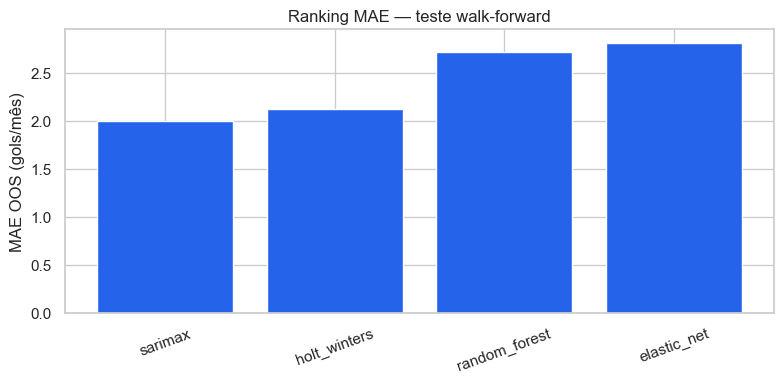

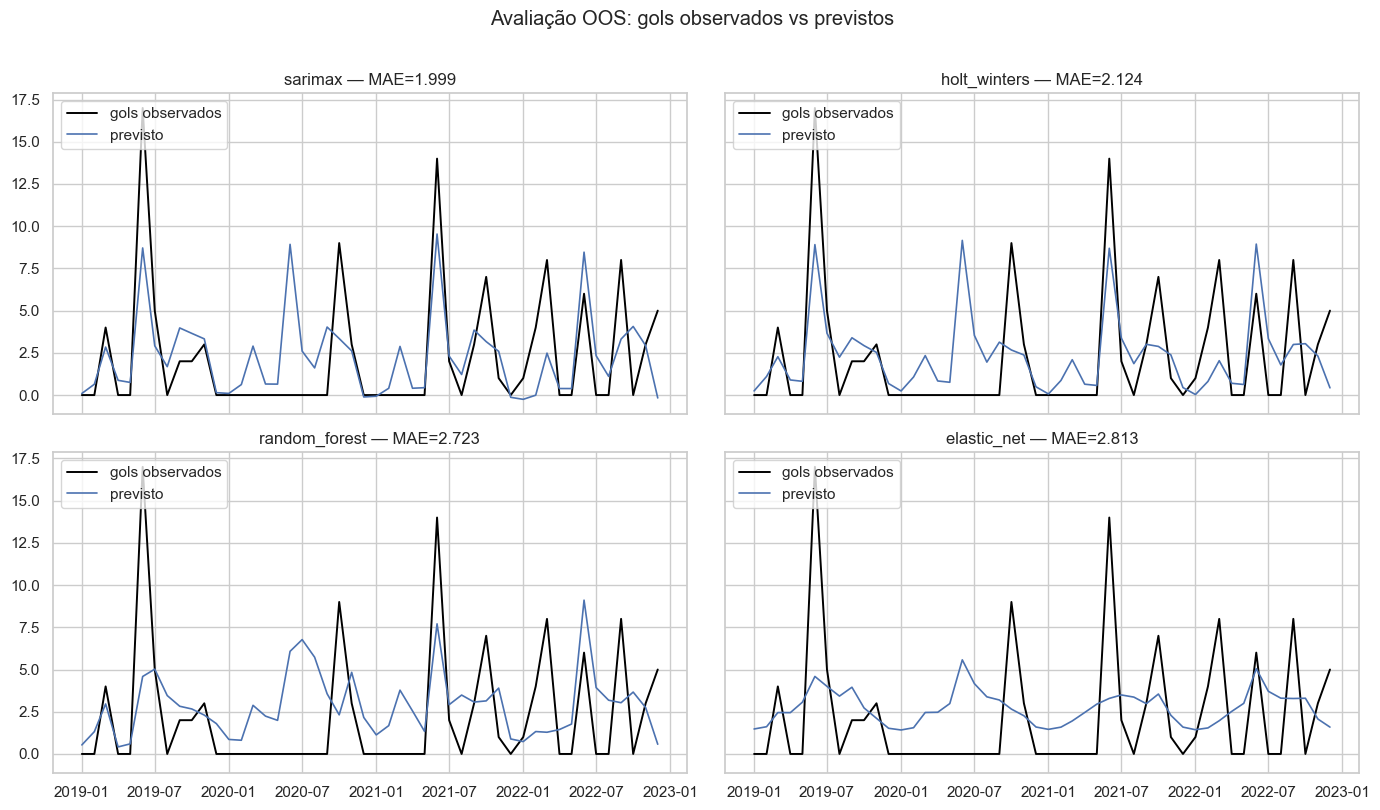

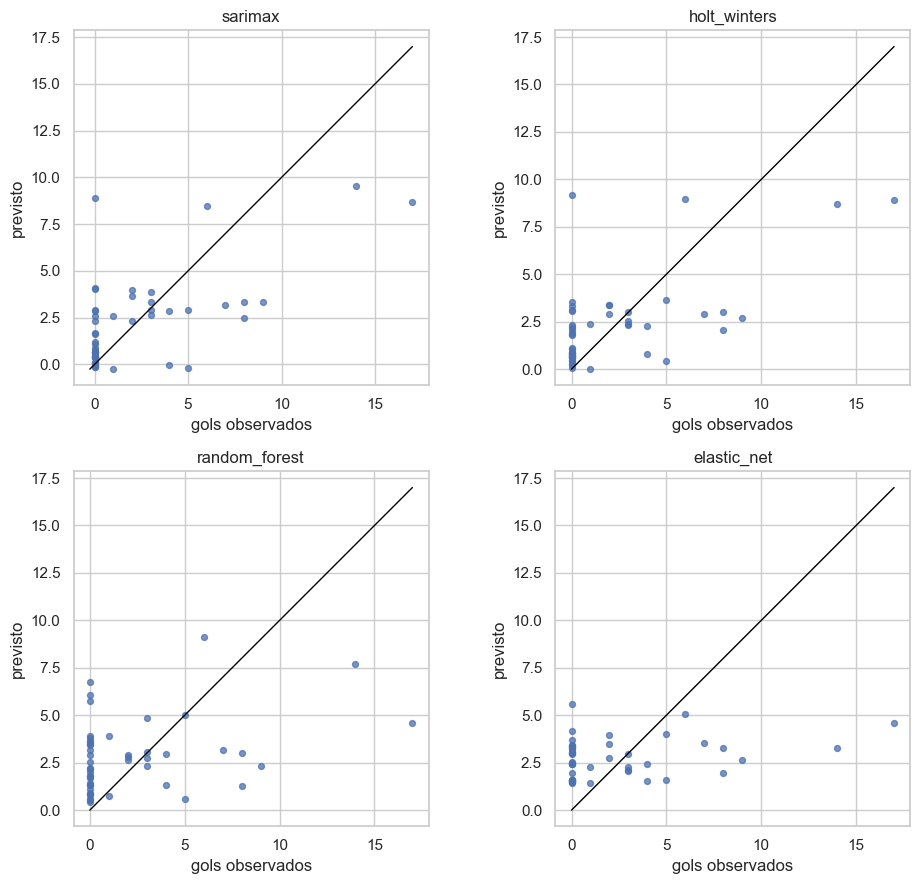

In [7]:
mae_rows = []
for model_name, pred_df in predictions.items():
    score = float(np.mean(np.abs(pred_df["y_true"] - pred_df["y_pred"])))
    mae_rows.append({
        "base_id": BASE_ID,
        "model": model_name,
        "mae": score,
        "n_predictions": len(pred_df),
    })
mae_table = pd.DataFrame(mae_rows).sort_values("mae").reset_index(drop=True)
mae_table["rank"] = np.arange(1, len(mae_table) + 1)
mae_table = mae_table[["base_id", "model", "mae", "rank", "n_predictions"]]
mae_table.to_csv(DATA_DIR / f"mae_{BASE_ID}.csv", index=False)
display(mae_table)
print("Vencedor nesta base:", mae_table.iloc[0]["model"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mae_table["model"], mae_table["mae"], color="#2563eb")
ax.set(ylabel="MAE OOS (gols/mês)", title="Ranking MAE — teste walk-forward")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.plot(pred_df["forecast_date"], pred_df["y_true"], label="gols observados", color="black", linewidth=1.4)
    ax.plot(pred_df["forecast_date"], pred_df["y_pred"], label="previsto", linewidth=1.2)
    ax.set_title(f"{model_name} — MAE={mae_table.loc[mae_table.model==model_name, 'mae'].iloc[0]:.3f}")
    ax.legend(loc="upper left")
fig.suptitle("Avaliação OOS: gols observados vs previstos", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.scatter(pred_df["y_true"], pred_df["y_pred"], s=18, alpha=0.75)
    lo = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
    hi = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set(xlabel="gols observados", ylabel="previsto", title=model_name, aspect="equal")
plt.tight_layout()
plt.show()

Interpretação (confirmar com a tabela executada acima): o alvo é uma contagem com muitos zeros e picos em meses de torneio, então modelos que só seguem o nível recente tendem a errar nos picos de junho/julho. Modelos que usam o mês do ano, `goals_for_lag_12` e o ciclo da Copa têm chance de capturar parte desse padrão. O Random Forest não extrapola além do que viu no treino e faz previsões por médias de folhas; o Elastic Net é linear, com shrinkage e seleção parcial de variáveis, mas depende de relações estáveis entre os lags e o alvo. Como o teste inclui 2020 (poucas partidas por causa da pandemia) e a Copa de 2022, o MAE é sensível a esses meses. A conclusão efetiva deve seguir a tabela executada.

## H. Resíduos OOS, ACF, PACF e Ljung–Box

Como `h=1` e cada origem avança um mês, os resíduos formam uma única sequência temporal sem sobreposição entre passos. Além da ACF, a PACF e o histograma mostram se resta estrutura linear ou assimetria. O Ljung–Box é calculado nos lags 6 e 12 (meio ano e um ano).

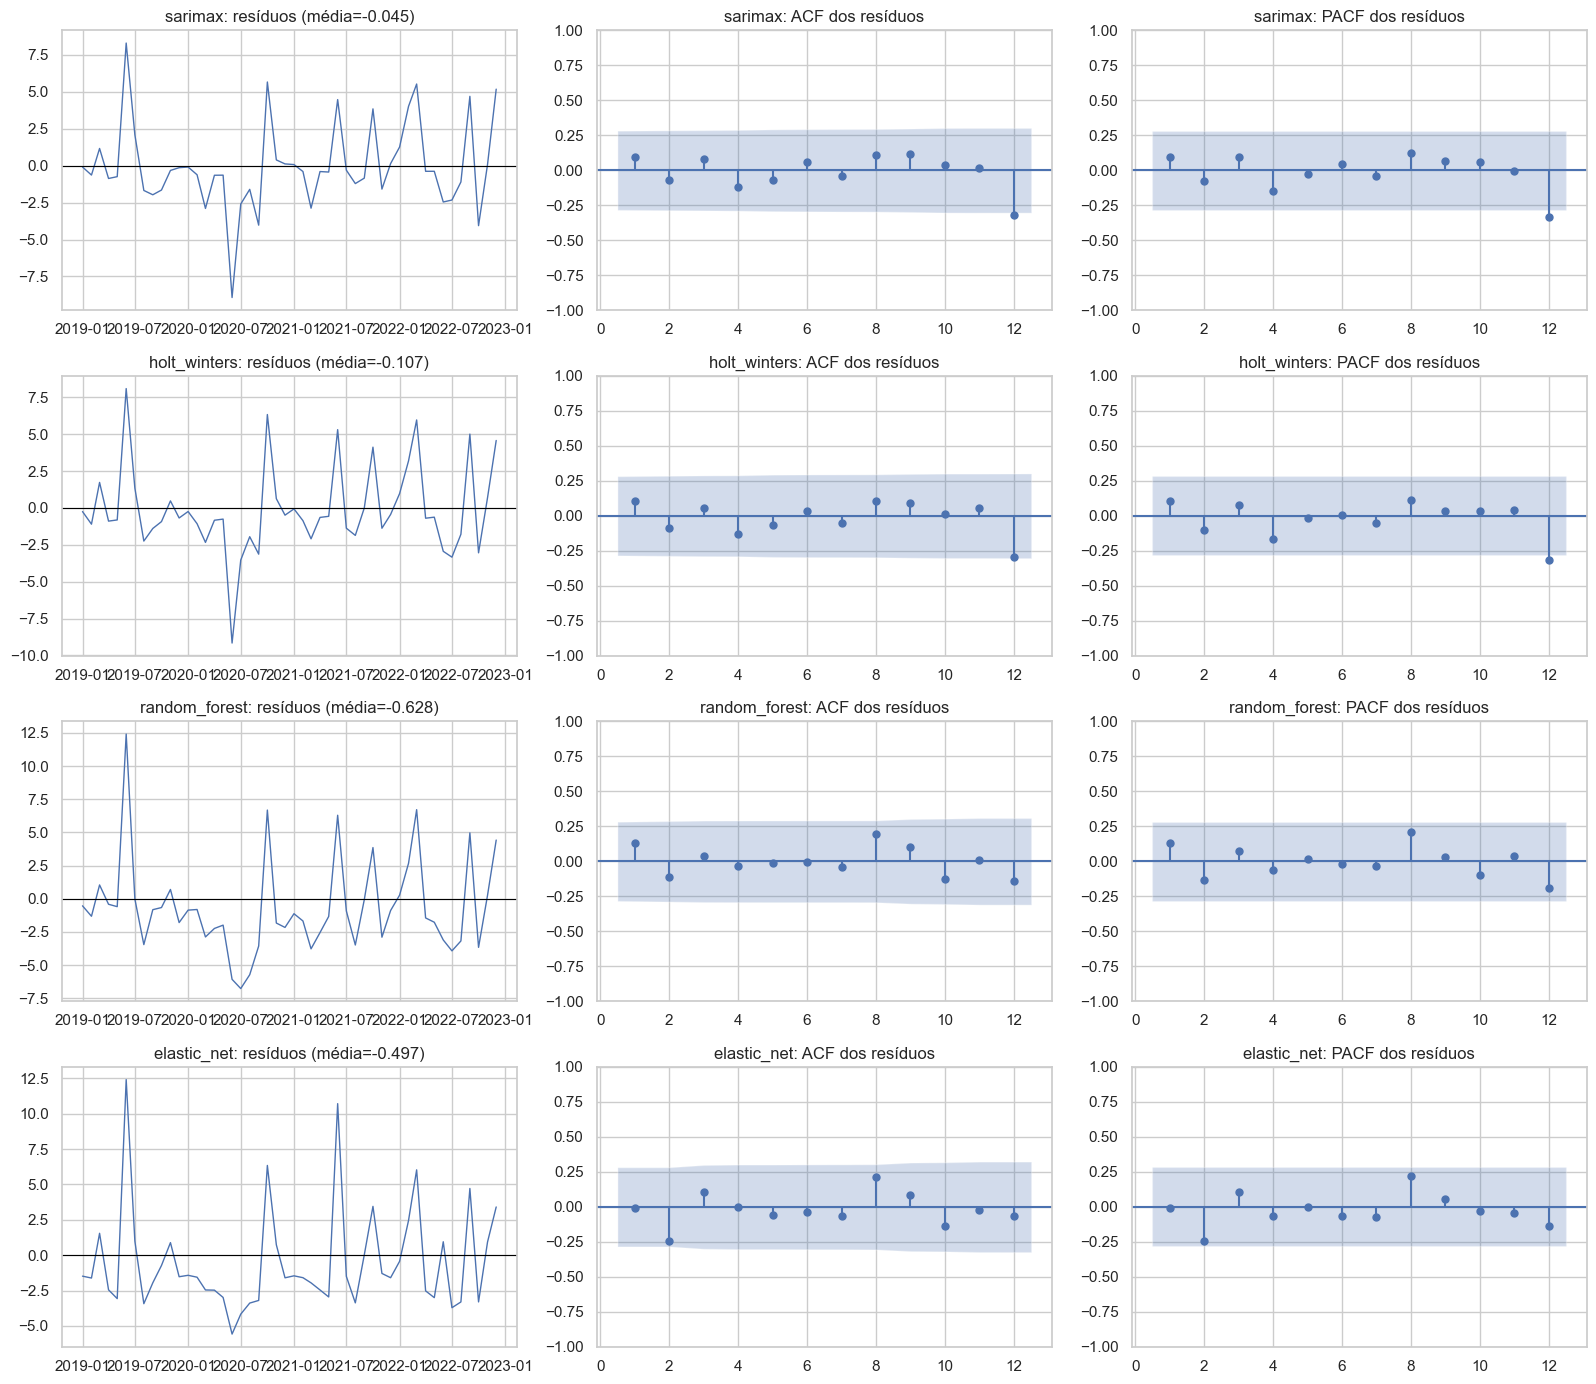

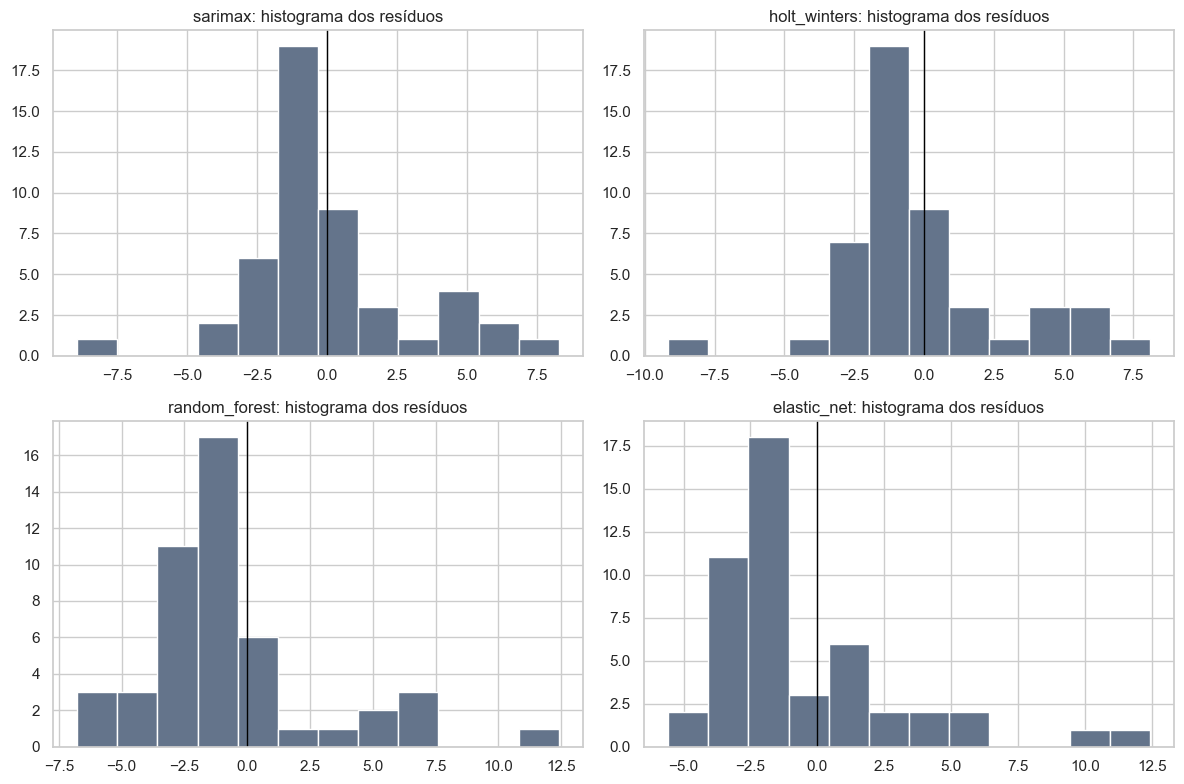

,base_id,model,horizon_step,lag,lb_stat,p_value,n_residuals
0,base_03,sarimax,1,6,2.288184,0.891379,48
1,base_03,sarimax,1,12,10.776582,0.548157,48
2,base_03,holt_winters,1,6,2.447039,0.874347,48
3,base_03,holt_winters,1,12,9.747836,0.638072,48
4,base_03,random_forest,1,6,1.670751,0.947357,48
5,base_03,random_forest,1,12,6.992995,0.858076,48
6,base_03,elastic_net,1,6,3.933920,0.685619,48
7,base_03,elastic_net,1,12,9.034989,0.699939,48


p < 0,05 indica evidência de autocorrelação residual no lag correspondente.


In [8]:
ljung_rows = []
fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 14))
for row_idx, model_name in enumerate(model_names):
    pred_df = predictions[model_name].copy()
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    residual_cols = key_cols + ["y_true", "y_pred", "residual"]
    pred_df[residual_cols].to_csv(DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv", index=False)
    residuals = pred_df["residual"]
    residual_lags = min(15, max(5, len(residuals) // 4))
    axes[row_idx, 0].plot(pred_df["forecast_date"], residuals, linewidth=1)
    axes[row_idx, 0].axhline(0, color="black", linewidth=0.8)
    axes[row_idx, 0].set_title(f"{model_name}: resíduos (média={residuals.mean():.3f})")
    plot_acf(residuals, lags=residual_lags, ax=axes[row_idx, 1], zero=False)
    axes[row_idx, 1].set_title(f"{model_name}: ACF dos resíduos")
    plot_pacf(residuals, lags=residual_lags, ax=axes[row_idx, 2], zero=False, method="ywm")
    axes[row_idx, 2].set_title(f"{model_name}: PACF dos resíduos")
    for lag in [6, 12]:
        lb = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
        ljung_rows.append({
            "base_id": BASE_ID,
            "model": model_name,
            "horizon_step": 1,
            "lag": lag,
            "lb_stat": float(lb["lb_stat"]),
            "p_value": float(lb["lb_pvalue"]),
            "n_residuals": len(residuals),
        })
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    residuals = predictions[model_name]["y_true"] - predictions[model_name]["y_pred"]
    ax.hist(residuals, bins=12, color="#64748b", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{model_name}: histograma dos resíduos")
plt.tight_layout()
plt.show()

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(DATA_DIR / f"ljung_box_{BASE_ID}.csv", index=False)
display(ljung_table)
print("p < 0,05 indica evidência de autocorrelação residual no lag correspondente.")

A média dos resíduos indica viés (positivo = subprevisão; negativo = sobreprevisão). A série temporal mostra mudanças de variabilidade e choques, sobretudo nos meses de torneio; a ACF e o Ljung–Box verificam se ainda resta dependência linear, inclusive sazonal (lag 12). Com apenas 48 resíduos, o teste tem poder limitado, e rejeitar ruído branco em algum modelo sugere dinâmica temporal não capturada, mesmo quando o MAE é competitivo.

## I. Importância e persistência dos modelos finais

Os modelos finais são reajustados com todas as observações disponíveis, depois de congeladas as previsões OOS. O `training_end` registra explicitamente esse uso do período de teste; ele não altera as métricas históricas.

Para a Permutation Importance do Random Forest, usamos um RF ajustado **só com o desenvolvimento** e embaralhamos as features no período de teste. Assim a importância é de fato fora da amostra; com o modelo final, que já viu o teste, ela não seria.

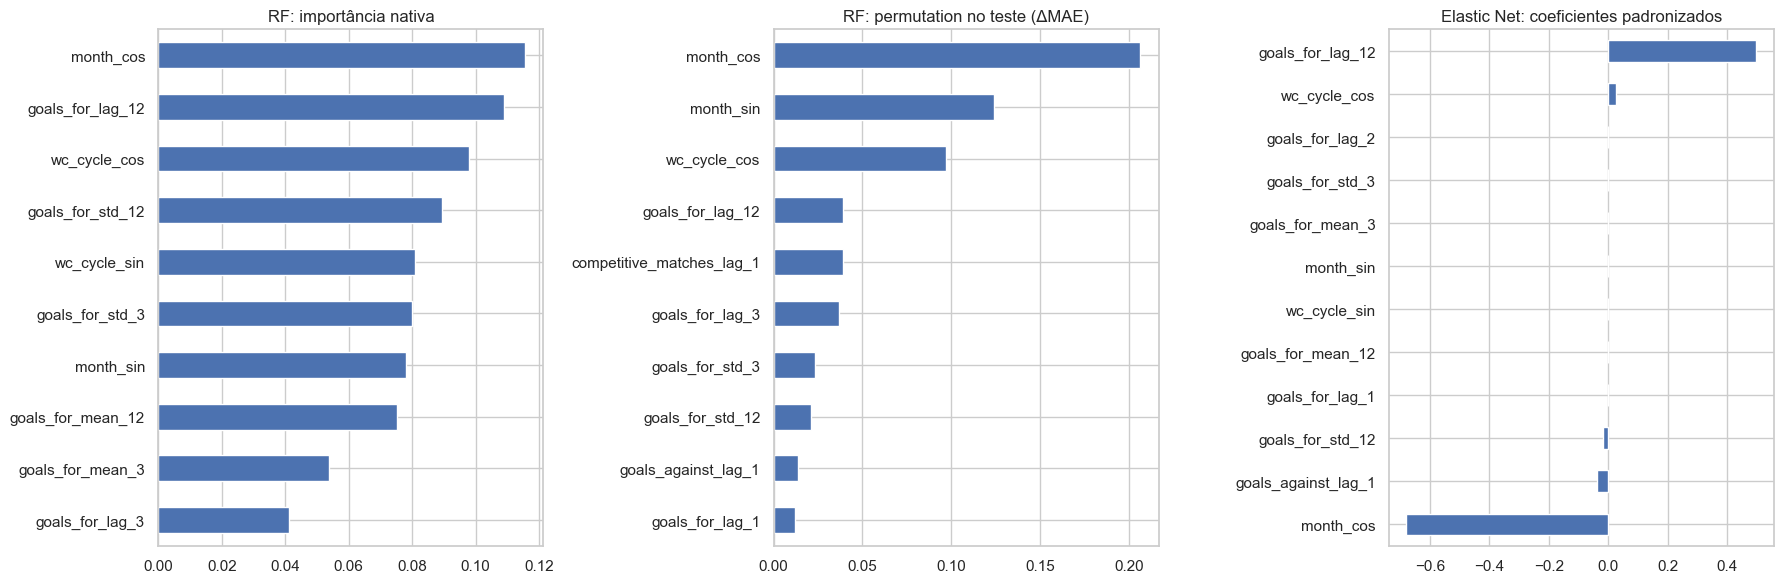

,rf_native,rf_permutation_test
month_cos,0.115603,0.206450
month_sin,0.078107,0.124067
wc_cycle_cos,0.098083,0.097187
goals_for_lag_12,0.108931,0.039263
competitive_matches_lag_1,0.023978,0.038896
goals_for_lag_3,0.041333,0.036754
goals_for_std_3,0.080124,0.023375
goals_for_std_12,0.089473,0.020776
goals_against_lag_1,0.024439,0.013893
goals_for_lag_1,0.035589,0.011790


,elastic_net_standardized_coefficient
month_cos,-0.678986
goals_for_lag_12,0.497609
goals_against_lag_1,-0.037590
wc_cycle_cos,0.025114
goals_for_std_12,-0.018790
goals_for_lag_1,-0.000000
goals_for_mean_12,-0.000000
wc_cycle_sin,-0.000000
month_sin,-0.000000
goals_for_mean_3,-0.000000


Coeficientes Elastic Net zerados: 12 de 17


,rf_native,rf_permutation_test,elastic_net_coef
matches_lag_1,0.026160,-0.024840,-0.00000
competitive_matches_lag_1,0.023978,0.038896,-0.00000
goals_against_lag_1,0.024439,0.013893,-0.03759
wins_lag_1,0.016433,-0.017326,-0.00000
is_wc_year,0.011706,-0.012608,-0.00000


,coefficient,p_value
matches_lag_1,0.168448,0.548915
competitive_matches_lag_1,-0.137069,0.590874
goals_against_lag_1,-0.196657,0.222679
is_wc_year,-0.021122,0.966133


Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.


In [9]:
full_x = samples[feature_cols]
full_y = samples["target"]

final_rf = clone(rf_base).set_params(**rf_params).fit(full_x, full_y)
final_en = clone(en_base).set_params(**en_params).fit(full_x, full_y)
final_sarimax = SARIMAX(
    full_y,
    exog=samples[sarimax_features],
    order=tuple(sarimax_params["order"]),
    seasonal_order=tuple(sarimax_params["seasonal_order"]),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=75)
final_hw = ExponentialSmoothing(
    full_y.to_numpy(),
    trend=hw_params["trend"],
    damped_trend=hw_params["damped_trend"],
    seasonal=hw_params["seasonal"],
    seasonal_periods=hw_params.get("seasonal_periods"),
    initialization_method="estimated",
).fit(optimized=True)

joblib.dump(final_rf, ARTIFACT_DIR / "random_forest.pkl")
joblib.dump(final_en, ARTIFACT_DIR / "elastic_net.pkl")
with open(ARTIFACT_DIR / "sarimax.pkl", "wb") as f:
    pickle.dump(final_sarimax, f)
with open(ARTIFACT_DIR / "holt_winters.pkl", "wb") as f:
    pickle.dump(final_hw, f)

version_info = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
}
selected_params = {
    "sarimax": sarimax_params,
    "holt_winters": hw_params,
    "random_forest": rf_params,
    "elastic_net": en_params,
}
for model_name in model_names:
    meta = {
        "base_id": BASE_ID,
        "model": model_name,
        "hyperparams": selected_params[model_name],
        "training_end": str(cleaned["Date"].max().date()),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "horizon": HORIZON,
        "multi_step_strategy": "direct_one_step",
        "versions": version_info,
    }
    with open(ARTIFACT_DIR / f"{model_name}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

rf_importance = pd.Series(final_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
en_coef = pd.Series(final_en.named_steps["model"].coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

# Permutation OOS de verdade: modelo treinado só no desenvolvimento, avaliado no teste.
rf_development_only = clone(rf_base).set_params(**rf_params).fit(development[feature_cols], development["target"])
perm = permutation_importance(
    rf_development_only,
    test_samples[feature_cols],
    test_samples["target"],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rf_importance.head(10).sort_values().plot.barh(ax=axes[0], title="RF: importância nativa")
perm_importance.head(10).sort_values().plot.barh(ax=axes[1], title="RF: permutation no teste (ΔMAE)")
en_coef.head(12).sort_values().plot.barh(ax=axes[2], title="Elastic Net: coeficientes padronizados")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"rf_native": rf_importance, "rf_permutation_test": perm_importance}).sort_values("rf_permutation_test", ascending=False).head(12))
display(en_coef.rename("elastic_net_standardized_coefficient").to_frame().head(12))
print("Coeficientes Elastic Net zerados:", int((en_coef == 0).sum()), "de", len(en_coef))

external_features = ["matches_lag_1", "competitive_matches_lag_1", "goals_against_lag_1", "wins_lag_1", "is_wc_year"]
display(pd.DataFrame({
    "rf_native": rf_importance.reindex(external_features),
    "rf_permutation_test": perm_importance.reindex(external_features),
    "elastic_net_coef": en_coef.reindex(external_features),
}))

sarimax_interpretation = pd.DataFrame({
    "coefficient": final_sarimax.params,
    "p_value": final_sarimax.pvalues,
})
display(sarimax_interpretation.loc[sarimax_interpretation.index.intersection(sarimax_features)])
print("Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.")

### Elastic Net — estudo local

Elastic Net minimiza o erro quadrático com uma penalização que combina L1 e L2. `l1_ratio=1` aproxima Lasso (esparsidade) e `l1_ratio=0` aproxima Ridge (shrinkage distribuído). Padronizar é indispensável porque a penalização depende da escala e porque torna os coeficientes comparáveis. O `StandardScaler` foi ajustado exclusivamente dentro de cada fold/prefixo de treino.

O `alpha` escolhido controla a intensidade total da regularização e o `l1_ratio` selecionado mostra o compromisso observado entre zerar coeficientes e estabilizar variáveis correlacionadas (aqui, várias features são parentes próximos: lags e médias móveis do mesmo alvo). A comparação com RF é justa porque ambos recebem a mesma matriz. Na interpretação, as defasagens de `matches`, `competitive_matches`, `goals_against` e `wins` são informação disponível na origem, e não valores do mês previsto; já `is_wc_year` e o ciclo da Copa são calendário conhecido antecipadamente.

In [10]:
# Validação final de artefatos e contratos.
required_data = [
    DATA_DIR / f"cleaned_{BASE_ID}.csv",
    DATA_DIR / f"features_{BASE_ID}.parquet",
    DATA_DIR / f"mae_{BASE_ID}.csv",
    DATA_DIR / f"ljung_box_{BASE_ID}.csv",
]
for model_name in model_names:
    required_data.extend([
        DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json",
    ])
    assert (ARTIFACT_DIR / f"{model_name}.pkl").exists()
    assert (ARTIFACT_DIR / f"{model_name}_meta.json").exists()
assert all(path.exists() and path.stat().st_size > 0 for path in required_data)

raw_after = pd.read_csv(RAW_FILE)
pd.testing.assert_frame_equal(raw, raw_after)
assert len(mae_table) == 4
assert mae_table["n_predictions"].nunique() == 1
assert np.isfinite(mae_table["mae"]).all()
print(f"VALIDAÇÃO FINAL OK: {len(required_data)} arquivos de dados e 8 artefatos de modelo.")
print("Raw preservado; notebook concluiu sem estado oculto.")

VALIDAÇÃO FINAL OK: 16 arquivos de dados e 8 artefatos de modelo.
Raw preservado; notebook concluiu sem estado oculto.
